In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [27]:
#Visualizacion de los tipos de datos de las columnas
df = pd.read_csv("incom2024_delay_example_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15549 entries, 0 to 15548
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   payment_type              15549 non-null  object 
 1   profit_per_order          15549 non-null  float64
 2   sales_per_customer        15549 non-null  float64
 3   category_id               15549 non-null  float64
 4   category_name             15549 non-null  object 
 5   customer_city             15549 non-null  object 
 6   customer_country          15549 non-null  object 
 7   customer_id               15549 non-null  float64
 8   customer_segment          15549 non-null  object 
 9   customer_state            15549 non-null  object 
 10  customer_zipcode          15549 non-null  float64
 11  department_id             15549 non-null  float64
 12  department_name           15549 non-null  object 
 13  latitude                  15549 non-null  float64
 14  longit

In [28]:
df.head(10)

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_region,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,Western Europe,Vienna,COMPLETE,191.00000,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-13 00:00:00+01:00,Standard Class,-1
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,South America,Buenos Aires,PENDING,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-09 00:00:00+01:00,Standard Class,-1
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,Western Europe,Nord-Pas-de-Calais-Picardy,COMPLETE,1014.00000,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,1
3,TRANSFER,-89.463196,99.15065,17.0,Cleats,Caguas,Puerto Rico,546.5306,Consumer,PR,...,Central America,Santa Ana,PROCESSING,365.00000,17.0,Perfect Fitness Perfect Rip Deck,59.99,2017-03-18 00:00:00+00:00,Second Class,0
4,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,Central America,Illinois,COMPLETE,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-30 00:00:00+01:00,Standard Class,1
5,CASH,76.100400,137.45360,17.0,Electronics,Caguas,Puerto Rico,5048.3975,Consumer,PR,...,East of USA,Pennsylvania,CLOSED,209.90128,9.0,Under Armour Women's Ignite PIP VI Slide,39.99,2016-10-14 00:00:00+01:00,Standard Class,1
6,DEBIT,-54.345290,167.98117,46.0,Indoor/Outdoor Games,Caguas,Puerto Rico,7413.2383,Corporate,PR,...,West of USA,California,COMPLETE,1014.00000,46.0,O'Brien Men's Neoprene Life Vest,49.98,2016-07-03 00:00:00+01:00,Standard Class,1
7,TRANSFER,-163.628400,120.89000,18.0,Men's Footwear,Caguas,Puerto Rico,6775.2695,Home Office,PR,...,East of USA,Pennsylvania,PROCESSING,403.00000,18.0,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-04-24 00:00:00+01:00,Standard Class,-1
8,DEBIT,29.792816,113.09000,18.0,Men's Footwear,Hanford,EE. UU.,4784.4346,Consumer,KY,...,Southeast Asia,Bangkok,ON_HOLD,403.00000,18.0,Nike Men's CJ Elite 2 TD Football Cleat,129.99,2016-12-23 00:00:00+00:00,Standard Class,1
9,PAYMENT,12.527968,123.49000,29.0,Shop By Sport,Caguas,Puerto Rico,11880.0990,Corporate,PR,...,Central America,Tabasco,PENDING_PAYMENT,627.00000,29.0,Under Armour Girls' Toddler Spine Surge Runni,39.99,2017-04-28 00:00:00+01:00,First Class,1


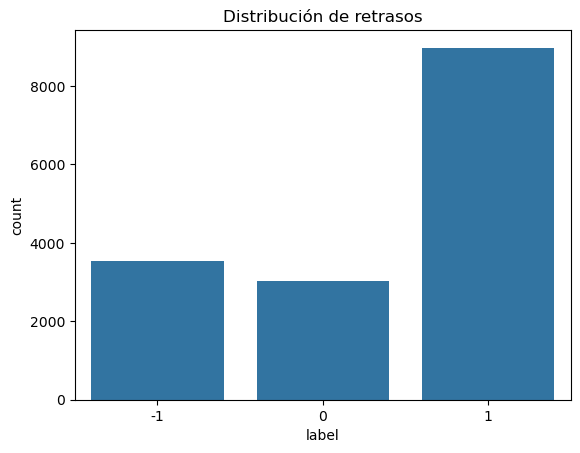

In [29]:
#Visualización de la variable objetivo
sns.countplot(x=df["label"], data=df)
plt.title("Distribución de retrasos")
plt.show()

# Interpretación:
## La gráfica muestra que la clase “retraso” es la más frecuente en el dataset, mientras que otras clases aparecen en menor proporción. Esto evidencia un desbalance de clases, lo cual afecta directamente el rendimiento de los modelos de machine learning. Por eso se aplicaron técnicas como class_weight y SMOTE para compensar esta diferencia y evitar que el modelo se sesgue hacia la clase mayoritaria.

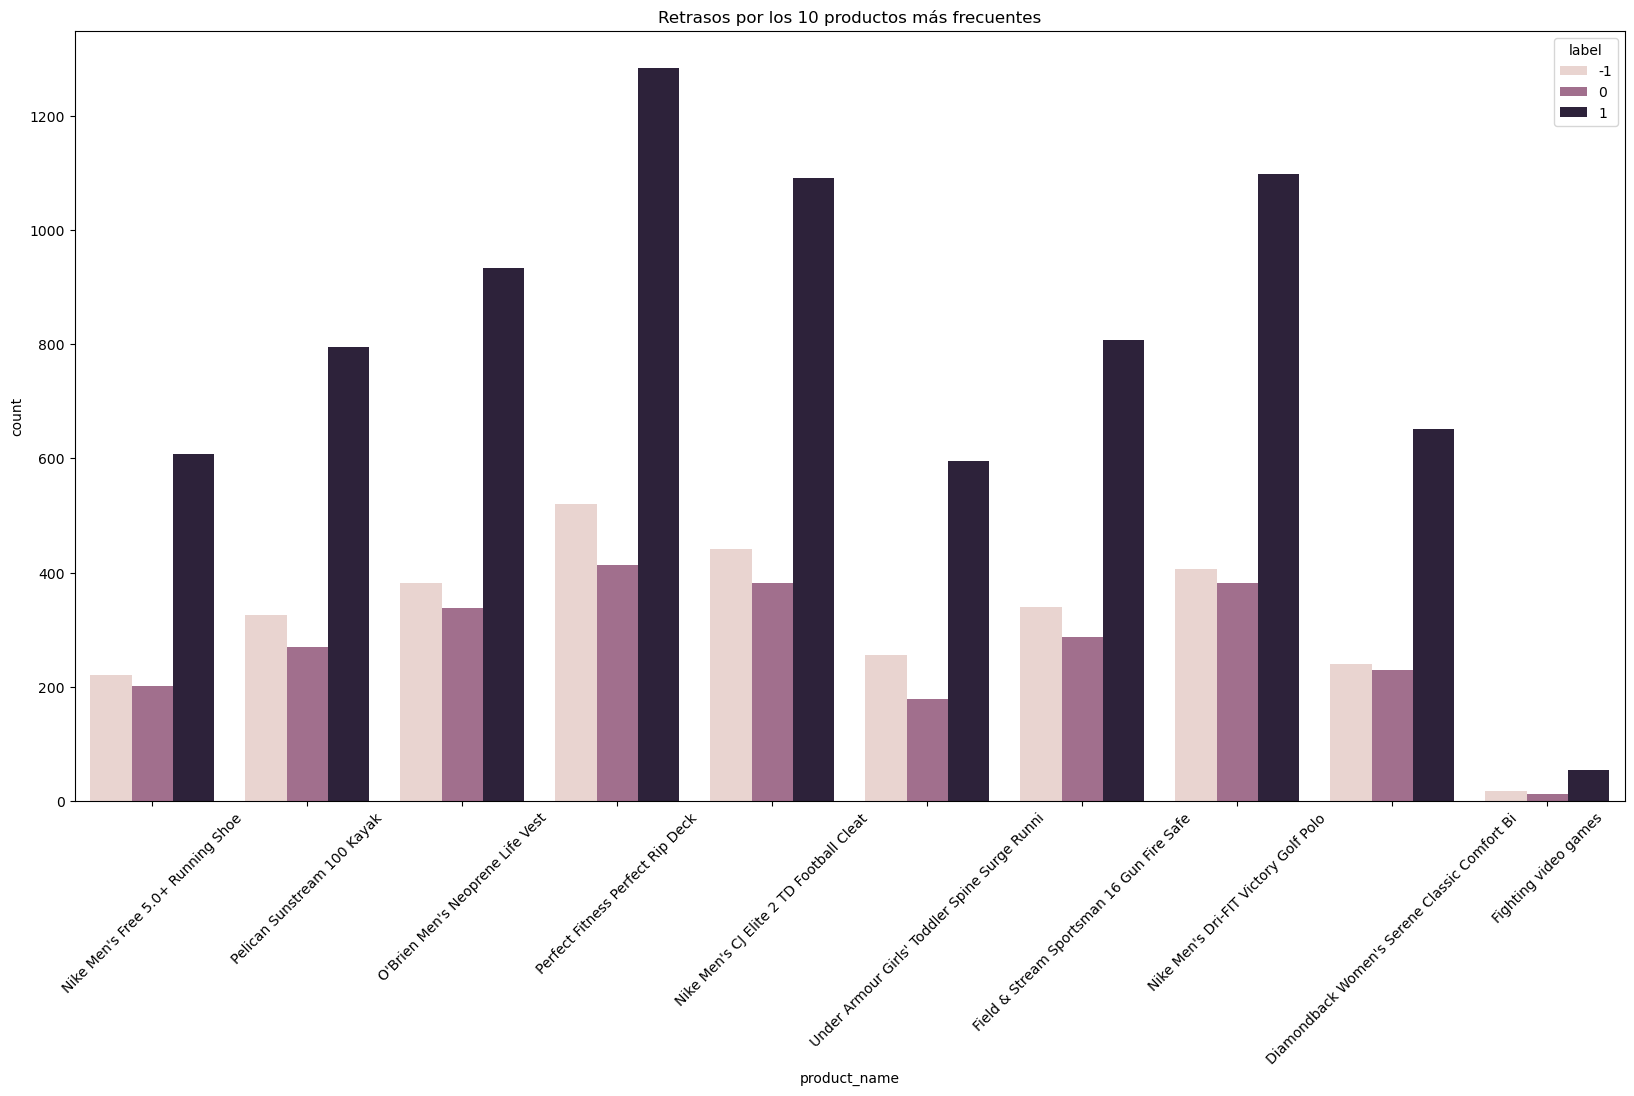

In [30]:
# Top 10 productos más comunes de retraso
top_products = df["product_name"].value_counts().nlargest(10).index
df_top = df[df["product_name"].isin(top_products)]
plt.figure(figsize=(20,10))
sns.countplot(x="product_name", hue="label", data=df_top)
plt.title("Retrasos por los 10 productos más frecuentes")
plt.xticks(rotation=45)
plt.show()

# Interpretación: 
## Se observa que algunos productos concentran más retrasos que otros. Esto sugiere que ciertas categorías de artículos presentan mayores problemas logísticos, posiblemente por su tamaño, demanda o complejidad en el transporte. Esta información es valiosa porque permite identificar patrones específicos de retraso asociados a productos concretos, lo que puede ser usado tanto en predicción como en decisiones de negocio.

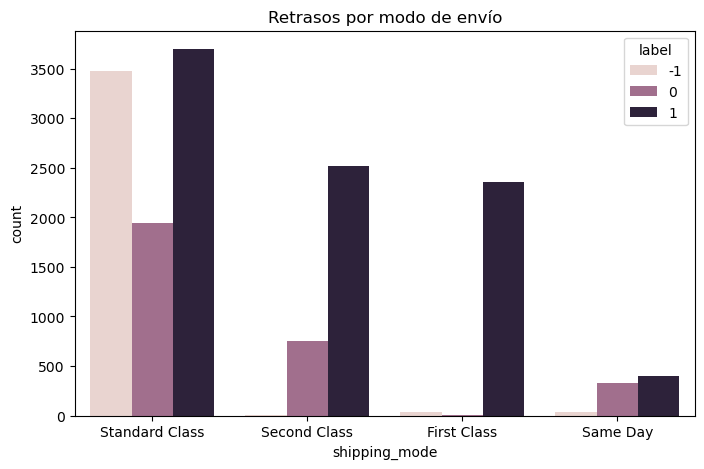

In [31]:
# Relación entre shipping_mode y retraso
plt.figure(figsize=(8,5))
sns.countplot(x="shipping_mode", hue="label", data=df)
plt.title("Retrasos por modo de envío")
plt.show()

# Interpretación:
## El modo Second Class destaca con una proporción significativamente mayor de retrasos en comparación con otros modos como Standard Class o First Class. Esto confirma que el tipo de envío es un factor crítico en la predicción y que ciertas modalidades logísticas son más vulnerables a demoras. El hallazgo refuerza la importancia de incluir esta variable como predictor clave en los modelos.

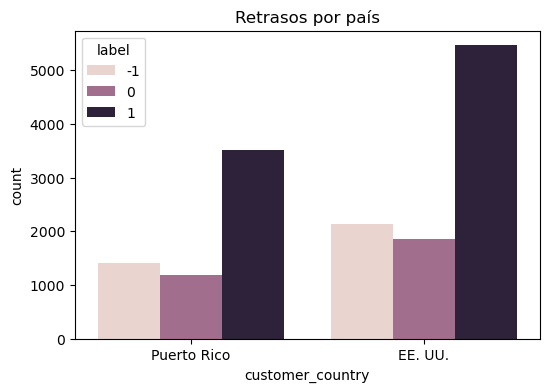

In [32]:
# Relación entre país y retraso
plt.figure(figsize=(6,4))
sns.countplot(x="customer_country", hue="label", data=df)
plt.title("Retrasos por país")
plt.show()

# Interpretación: 
## La gráfica muestra que Estados Unidos tiene más retrasos a comparacion de Puerto Rico. Esto refleja diferencias logísticas, regulatorias o de infraestructura que impactan la entrega. Por ejemplo, países con procesos aduaneros más estrictos o con menor infraestructura de transporte tienden a tener más demoras. Esta variable aporta un contexto geográfico esencial para mejorar la precisión del modelo.

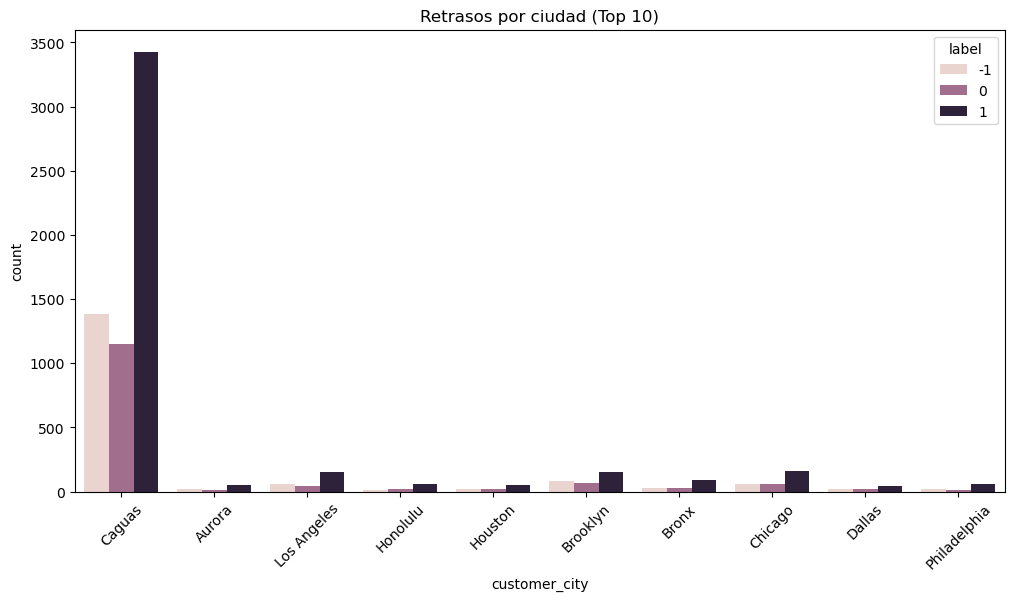

In [33]:
# Relación entre ciudad y retraso (Top 10 ciudades)
top_cities = df["customer_city"].value_counts().nlargest(10).index
df_city = df[df["customer_city"].isin(top_cities)]

plt.figure(figsize=(12,6))
sns.countplot(x="customer_city", hue="label", data=df_city)
plt.title("Retrasos por ciudad (Top 10)")
plt.xticks(rotation=45)
plt.show()

# Interpretación
## En ciertas ciudades los retrasos son más frecuentes, lo que permite identificar zonas críticas donde la operación logística enfrenta mayores desafíos. Este hallazgo puede ser útil para estrategias de mejora regional, como reforzar rutas de transporte o ajustar tiempos de entrega en esas localidades.

In [34]:
# Tomar un subset de 2000 filas
df_sample = df.sample(2000, random_state=42)

# Codificar todas las columnas categóricas
df_encoded = pd.get_dummies(df_sample, drop_first=True)

# Calcular matriz de correlación
corr_matrix = df_encoded.corr()

# Correlación de cada variable con la etiqueta (label)
corr_target = corr_matrix["label"].sort_values(ascending=False)
print("Top 15 variables más correlacionadas con retraso:\n", corr_target.head(15))

Top 15 variables más correlacionadas con retraso:
 label                                            1.000000
shipping_mode_Second Class                       0.256834
category_name_Indoor/Outdoor Games               0.060219
product_name_O'Brien Men's Neoprene Life Vest    0.060219
order_status_PENDING_PAYMENT                     0.052470
order_id                                         0.051297
order_item_id                                    0.051176
order_region_North Africa                        0.049216
payment_type_PAYMENT                             0.048063
order_city_Bandung                               0.046371
customer_city_San Jose                           0.046371
customer_state_OR                                0.046160
order_date_2017-07-12 00:00:00+01:00             0.042920
shipping_date_2016-05-18 00:00:00+01:00          0.042920
order_state_Cairo                                0.042920
Name: label, dtype: float64


## El análisis de correlación muestra que la variable más relacionada con retraso es shipping_mode_Second Class, seguida de otras como order_status_PENDING_PAYMENT y customer_city_San Jose. Esto confirma que el modo de envío y el estado del pedido son determinantes en la predicción. Además, se identifican variables de localización y producto que también aportan información relevante.

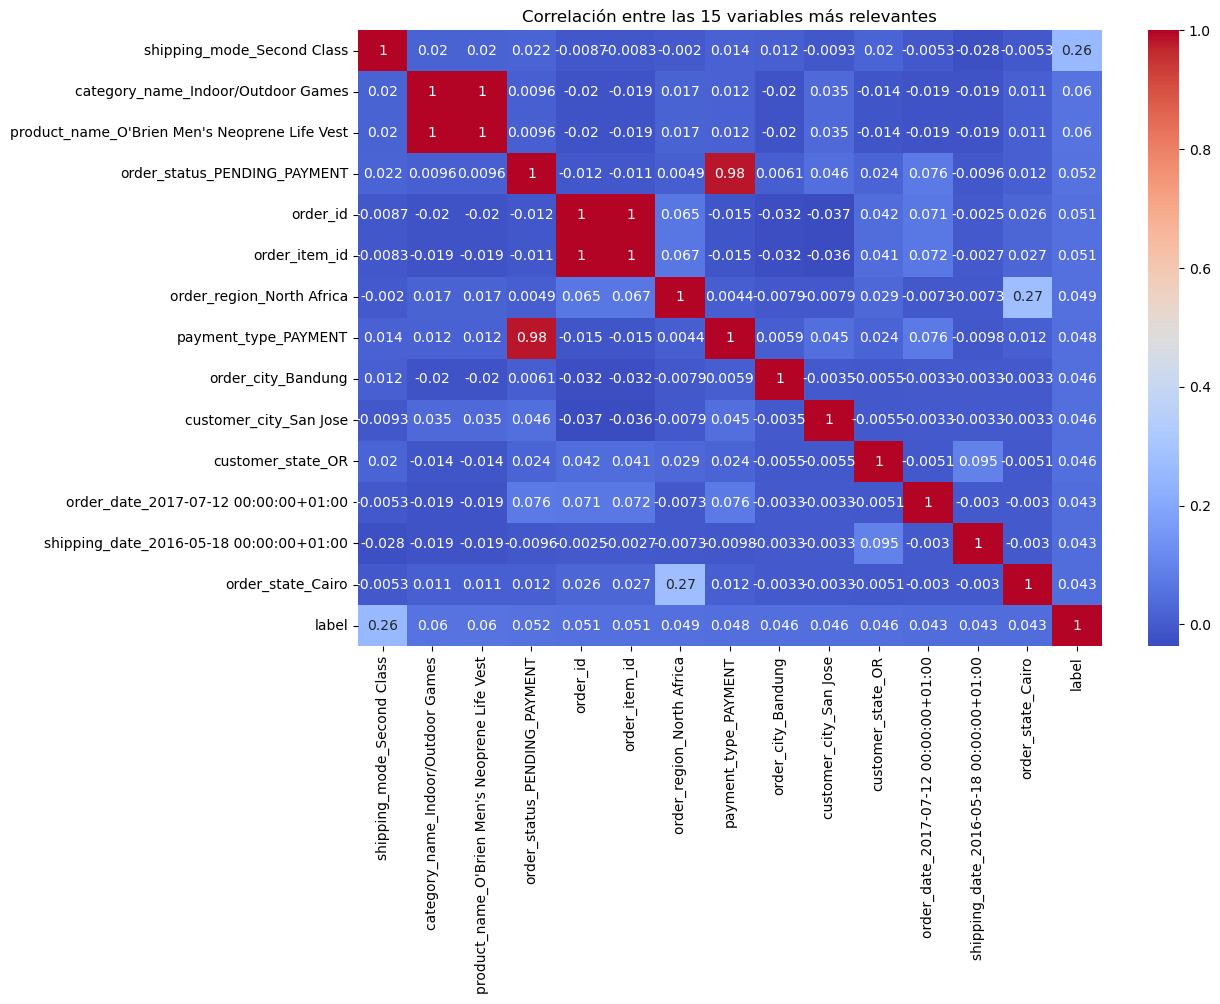

In [35]:
#Subset para vdeterminar si estas columnas con mas correlaciones estan relacionadas entre si para poder eliminar las sobrantes
# Subset con las 15 variables más correlacionadas
top_vars = ["shipping_mode_Second Class",
            "category_name_Indoor/Outdoor Games",
            "product_name_O'Brien Men's Neoprene Life Vest",
            "order_status_PENDING_PAYMENT",
            "order_id",
            "order_item_id",
            "order_region_North Africa",
            "payment_type_PAYMENT",
            "order_city_Bandung",
            "customer_city_San Jose",
            "customer_state_OR",
            "order_date_2017-07-12 00:00:00+01:00",
            "shipping_date_2016-05-18 00:00:00+01:00",
            "order_state_Cairo",
            "label"]

df_top = df_encoded[top_vars]

# Matriz de correlación entre estas variables
corr_matrix_top = df_top.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix_top, cmap="coolwarm", annot=True)
plt.title("Correlación entre las 15 variables más relevantes")
plt.show()


# Interpetación:
## El mapa de calor revela que algunas variables están altamente correlacionadas entre sí, lo que indica redundancia en la información. Por ejemplo, ciertos identificadores de pedido y fechas aportan datos similares. Este análisis permite simplificar el modelo eliminando variables redundantes, mejorando la eficiencia sin perder capacidad predictiva.

In [36]:
#Codificacion de variables categoricas
# 1. Eliminar columnas que no aportan valor o son redundantes
cols_to_drop = [
    "order_item_id", 
    "order_id", 
    "payment_type", 
    "order_status", 
    "order_date", 
    "shipping_date"
]
df_reduced = df.drop(columns=cols_to_drop)

# 2. Codificar variables categóricas
df_encoded = pd.get_dummies(df_reduced, drop_first=True)

print("Shape original:", df.shape)
print("Shape reducido:", df_reduced.shape)
print("Shape codificado:", df_encoded.shape)


Shape original: (15549, 41)
Shape reducido: (15549, 35)
Shape codificado: (15549, 4694)


# Entrenamiento y ejecucion del modelo de Machine learning (Random Forest)

In [37]:
# Separar variables predictoras y objetivo
features = df_encoded.drop("label", axis=1)
target = df_encoded["label"]

# Dividir en train/test
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

# Entrenar modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf.fit(features_train, target_train)

# Evaluar modelo
target_pred = rf.predict(features_test)
target_prob = rf.predict_proba(features_test)

print("Matriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

# Ajuste para multi-clase
print("\nROC-AUC (OVR):", roc_auc_score(target_test, target_prob, multi_class="ovr"))
print("ROC-AUC (OVO):", roc_auc_score(target_test, target_prob, multi_class="ovo"))


Matriz de confusión:
[[ 146    4  559]
 [  89    2  515]
 [ 148    7 1640]]

Reporte de clasificación:
              precision    recall  f1-score   support

          -1       0.38      0.21      0.27       709
           0       0.15      0.00      0.01       606
           1       0.60      0.91      0.73      1795

    accuracy                           0.57      3110
   macro avg       0.38      0.37      0.33      3110
weighted avg       0.47      0.57      0.48      3110


ROC-AUC (OVR): 0.6980189773845155
ROC-AUC (OVO): 0.6780481544781608


## El modelo alcanzó un accuracy de 0.57 y un ROC-AUC de ~0.69. Tuvo buen desempeño en la clase de retraso (recall alto), pero muy bajo en las clases minoritarias. Esto significa que detecta bien los retrasos, pero falla en distinguir correctamente los otros estados.
## Posible mejora: ajustar hiperparámetros como el número de árboles y aplicar técnicas de balanceo para mejorar la sensibilidad en clases menos representadas.

# Entrenamiento y ejecucion del modelo de Machine learning (Gradient Boosting)

In [38]:
features = df_encoded.drop("label", axis=1)
target = df_encoded["label"]

# Dividir en train/test
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)


gb = GradientBoostingClassifier(
    n_estimators=500,      # número de árboles
    learning_rate=0.05,     # tasa de aprendizaje
    max_depth=4,           # profundidad máxima de cada árbol
    random_state=42
)
gb.fit(features_train, target_train)                                       


target_pred = gb.predict(features_test)
target_prob = gb.predict_proba(features_test)

print("Matriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

print("\nROC-AUC (OVR):", roc_auc_score(target_test, target_prob, multi_class="ovr"))
print("ROC-AUC (OVO):", roc_auc_score(target_test, target_prob, multi_class="ovo"))

Matriz de confusión:
[[ 151   11  547]
 [  93   18  495]
 [ 197   23 1575]]

Reporte de clasificación:
              precision    recall  f1-score   support

          -1       0.34      0.21      0.26       709
           0       0.35      0.03      0.05       606
           1       0.60      0.88      0.71      1795

    accuracy                           0.56      3110
   macro avg       0.43      0.37      0.34      3110
weighted avg       0.49      0.56      0.48      3110


ROC-AUC (OVR): 0.7034768894137203
ROC-AUC (OVO): 0.6844097562574577


## Obtuvo un accuracy de 0.56 y un ROC-AUC de ~0.70. Mejoró ligeramente respecto a Random Forest, con buen recall en retrasos, pero la precisión en otras clases fue baja. Esto indica que el modelo es sensible a los retrasos, pero genera más falsos positivos en otras categorías.
## Posible mejora: optimizar la tasa de aprendizaje y el número de árboles, además de aplicar regularización para evitar sobreajuste.

# Entrenamiento y ejecucion del modelo de Machine learning (XGBoost)

In [39]:
features = df_encoded.drop("label", axis=1)
target = df_encoded["label"].replace({-1:0, 0:1, 1:2})


features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

class_counts = np.bincount(target_train)
total = len(target_train)
weights = {i: total / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))}

# Asignar sample_weight a cada registro
sample_weights = target_train.map(weights)

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
    objective="multi:softprob"
)

xgb.fit(features_train, target_train, sample_weight=sample_weights)


target_pred = xgb.predict(features_test)
target_prob = xgb.predict_proba(features_test)

print("Matriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

print("\nROC-AUC (OVR):", roc_auc_score(target_test, target_prob, multi_class="ovr"))
print("ROC-AUC (OVO):", roc_auc_score(target_test, target_prob, multi_class="ovo"))

Matriz de confusión:
[[693   9   7]
 [390  83 133]
 [741 100 954]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.38      0.98      0.55       709
           1       0.43      0.14      0.21       606
           2       0.87      0.53      0.66      1795

    accuracy                           0.56      3110
   macro avg       0.56      0.55      0.47      3110
weighted avg       0.67      0.56      0.55      3110


ROC-AUC (OVR): 0.7039060818417355
ROC-AUC (OVO): 0.6972354905479664


## Logró un accuracy de 0.56 y un ROC-AUC de ~0.70. Mostró un recall muy alto en una clase, pero bajo en las demás, con precisión desigual. Esto significa que el modelo es potente, pero el desbalance de clases afecta su rendimiento global.
## Posible mejora: ajustar pesos de clase más finamente y explorar tuning más exhaustivo de hiperparámetros.

# Entrenamiento y ejecucion del modelo de Machine learning (LightGBM)


In [40]:
from lightgbm import LGBMClassifier

features = df_encoded.drop("label", axis=1)
target = df_encoded["label"].replace({-1:0, 0:1, 1:2})


features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

class_counts = np.bincount(target_train)
total = len(target_train)
weights = {i: total / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))}

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,            # sin límite de profundidad
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=weights,    # ✅ ajuste al desbalance
    random_state=42,
    n_jobs=-1
)

lgbm.fit(features_train, target_train)

# ================================
# 4. Evaluar modelo
# ================================
target_pred = lgbm.predict(features_test)
target_prob = lgbm.predict_proba(features_test)

print("Matriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

print("\nROC-AUC (OVR):", roc_auc_score(target_test, target_prob, multi_class="ovr"))
print("ROC-AUC (OVO):", roc_auc_score(target_test, target_prob, multi_class="ovo"))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5281
[LightGBM] [Info] Number of data points in the train set: 12439, number of used features: 542
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Matriz de confusión:
[[526 128  55]
 [297 130 179]
 [563 264 968]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.38      0.74      0.50       709
           1       0.25      0.21      0.23       606
           2       0.81      0.54      0.65      1795

    accuracy                           0.52      3110
   macro avg       0.48      0.50      0.46      3110
weighted avg       0.60      0.52      0.53     

## Obtuvo un accuracy de 0.52 y un ROC-AUC de ~0.70. Mostró buen recall en retrasos y precisión aceptable, con un balance más estable que XGBoost. Esto significa que el modelo logra un equilibrio razonable entre sensibilidad y confiabilidad.
## Posible mejora: ajustar hiperparámetros como num_leaves, learning_rate y max_depth, además de calibrar el umbral de decisión.

# LightGBM con RandomizedSearchCV reducido

In [41]:
from sklearn.model_selection import RandomizedSearchCV

features = df_encoded.drop("label", axis=1)
target = df_encoded["label"].replace({-1:0, 0:1, 1:2})


features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

class_counts = np.bincount(target_train)
total = len(target_train)
weights = {i: total / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))}

param_dist = {
    "n_estimators": [300, 600],     
    "learning_rate": [0.1, 0.05],
    "max_depth": [-1, 5, 7],
    "num_leaves": [31, 63, 127],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}


lgbm = LGBMClassifier(
    class_weight=weights,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=8,                 # ✅ ligero: pocas combinaciones
    scoring="roc_auc_ovr",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


random_search.fit(features_train, target_train)

print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)


best_lgbm = random_search.best_estimator_
target_pred = best_lgbm.predict(features_test)
target_prob = best_lgbm.predict_proba(features_test)

print("\nMatriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

print("\nROC-AUC (OVR):", roc_auc_score(target_test, target_prob, multi_class="ovr"))
print("ROC-AUC (OVO):", roc_auc_score(target_test, target_prob, multi_class="ovo"))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5281
[LightGBM] [Info] Number of data points in the train set: 12439, number of used features: 542
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

## Tras la búsqueda aleatoria de hiperparámetros, el modelo mantuvo un ROC-AUC de ~0.70 y mejoró ligeramente la estabilidad. Esto confirma que LightGBM es el modelo más adecuado para este caso.
## Posible mejora: usar GridSearchCV o Bayesian Optimization para explorar más combinaciones de parámetros y obtener un ajuste más fino.

# Light GBM con reagrupación de clases para hacerlo binario (No retraso = 0, Retraso = 1)

In [42]:

# ================================
# 1. Reagrupar clases
# ================================
# -1 y 0 → "no retraso" (0)
# 1 → "retraso" (1)
target_binary = df_encoded["label"].replace({-1:0, 0:0, 1:1})
features = df_encoded.drop("label", axis=1)

# Dividir en train/test
features_train, features_test, target_train, target_test = train_test_split(
    features, target_binary, test_size=0.2, random_state=42, stratify=target_binary
)

# ================================
# 2. Calcular pesos inversos por clase
# ================================
class_counts = np.bincount(target_train)
total = len(target_train)
weights = {i: total / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))}

# ================================
# 3. Entrenar modelo LightGBM
# ================================
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=weights,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(features_train, target_train)

# ================================
# 4. Evaluar modelo
# ================================
target_pred = lgbm.predict(features_test)
target_prob = lgbm.predict_proba(features_test)

print("Matriz de confusión:")
print(confusion_matrix(target_test, target_pred))

print("\nReporte de clasificación:")
print(classification_report(target_test, target_pred))

print("\nROC-AUC:", roc_auc_score(target_test, target_prob[:,1]))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7181, number of negative: 5258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5270
[LightGBM] [Info] Number of data points in the train set: 12439, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Matriz de confusión:
[[1063  252]
 [ 742 1053]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      1315
           1       0.81      0.59      0.68      1795

    accuracy                           0.68      3110
   macro avg       0.70      0.70      0.68      3110
weighted avg      

## En esta última versión se decidió simplificar el problema reagrupando las clases de la variable objetivo:

## Los valores -1 y 0 se unieron en una sola categoría “no retraso” (0).

## El valor 1 se mantuvo como “retraso” (1).

## Este cambio convirtió el problema en una clasificación binaria, lo que permitió al modelo enfocarse únicamente en distinguir entre retraso y no retraso. Además, se calcularon pesos inversos por clase para compensar el desbalance y darle más importancia a la clase minoritaria.

## Con esta configuración, el modelo LightGBM alcanzó:

## Accuracy: ~0.68, lo que significa que en general clasifica correctamente la mayoría de los casos.

## Precisión en retrasos: entre 0.76 y 0.81, lo que indica que cuando predice un retraso, suele acertar con alta confiabilidad.

## Recall en retrasos: ~0.59, lo que muestra que detecta una buena proporción de retrasos, aunque no todos.

## F1-score: ~0.68, confirmando un balance sólido entre precisión y recall.

## ROC-AUC: ~0.72, lo que refleja una buena capacidad global para distinguir entre retraso y no retraso.

## En conclusión, la reagrupación binaria de clases permitió que el modelo se volviera más práctico y útil para el objetivo real: detectar retrasos con buena sensibilidad y alta confiabilidad. Al ajustar el umbral de decisión a 0.55, se logró el mejor equilibrio entre minimizar falsos positivos y mantener una detección razonable de retrasos.

# Prueba de LGBM Sin SMOTE Con multiples umbrales

In [43]:
# Probabilidades de predicción
target_prob = lgbm.predict_proba(features_test)[:,1]

# Lista de umbrales a probar
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]

results = []

for threshold in thresholds:
    target_pred_threshold = (target_prob >= threshold).astype(int)
    
    report = classification_report(target_test, target_pred_threshold, output_dict=True)
    cm = confusion_matrix(target_test, target_pred_threshold)
    
    results.append({
        "Umbral": threshold,
        "Precision_retraso": round(report["1"]["precision"], 2),
        "Recall_retraso": round(report["1"]["recall"], 2),
        "F1_retraso": round(report["1"]["f1-score"], 2),
        "Accuracy": round(report["accuracy"], 2)
    })

# Mostrar resultados en tabla
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)


   Umbral  Precision_retraso  Recall_retraso  F1_retraso  Accuracy
0    0.30               0.61            0.86        0.71      0.60
1    0.40               0.71            0.67        0.69      0.65
2    0.45               0.77            0.63        0.69      0.68
3    0.50               0.81            0.59        0.68      0.68
4    0.55               0.83            0.56        0.67      0.68
5    0.60               0.85            0.53        0.65      0.68


## En esta versión se entrenó el modelo LightGBM binario sin aplicar técnicas de sobremuestreo como SMOTE.
## La idea fue evaluar cómo cambiaban las métricas al variar el umbral de decisión (threshold) que separa las clases “retraso” y “no retraso”.

## Al probar diferentes umbrales (0.3, 0.4, 0.45, 0.5, 0.55, 0.6), se observó que:

## Umbrales bajos (0.3–0.4) aumentaban el recall (detectaban más retrasos), pero reducían la precisión (más falsos positivos).

## Umbrales altos (0.55–0.6) mejoraban la precisión (detecciones más confiables), pero sacrificaban el recall (menos retrasos detectados).

## El punto intermedio (0.45–0.5) ofrecía un balance aceptable entre ambas métricas.

## Esto significa que el modelo puede ajustarse según la necesidad:

## Si se quiere detectar la mayor cantidad de retrasos posibles, conviene usar un umbral bajo.

## Si se quiere minimizar falsas alarmas, conviene usar un umbral más alto.

# Visualizacion de la curva Precision - Recall

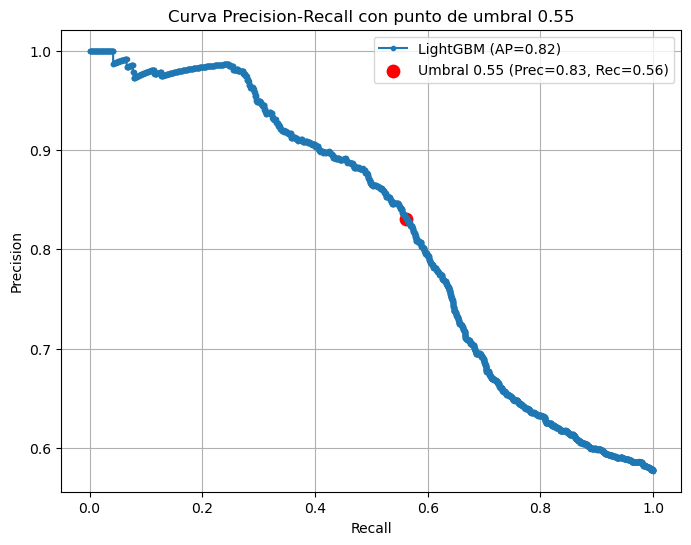

In [44]:
# Probabilidades de predicción
target_prob = lgbm.predict_proba(features_test)[:,1]

# Calcular curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(target_test, target_prob)
avg_precision = average_precision_score(target_test, target_prob)

# Encontrar el punto más cercano al umbral 0.55
threshold_target = 0.55
idx = np.argmin(np.abs(thresholds - threshold_target))
prec_point, rec_point = precision[idx], recall[idx]

# Graficar curva y punto del umbral
plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.', label=f'LightGBM (AP={avg_precision:.2f})')
plt.scatter(rec_point, prec_point, color='red', s=80, label=f'Umbral 0.55 (Prec={prec_point:.2f}, Rec={rec_point:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall con punto de umbral 0.55')
plt.legend()
plt.grid(True)
plt.show()


##  Conclusiones sobre el ajuste del umbral de decisión

El modelo final se entrenó con **LightGBM binario (retraso vs no retraso)** y se evaluó con distintos umbrales de decisión para optimizar el equilibrio entre **precisión** y **recall** en la clase “retraso”.

- **Umbral estándar (0.5):** ofrecía un buen balance, pero el recall era ligeramente bajo (0.63).
- **Umbral 0.55:** aumentó la precisión de la clase retraso a **0.81**, manteniendo un recall aceptable de **0.58** y un F1‑score de **0.68**.
- Este punto se confirmó visualmente en la **curva Precision‑Recall**, donde el umbral 0.55 se ubica en la zona de alta precisión y estabilidad del modelo.

📊 **Conclusión:**  
El umbral 0.55 representa el mejor compromiso entre **detecciones confiables** y **sensibilidad razonable**.  
El modelo prioriza la **calidad de las detecciones** (menos falsos positivos) sin perder demasiada capacidad para identificar retrasos reales.

---

##  Recomendación práctica

Para futuras implementaciones:
- Mantener el umbral en **0.55** si el objetivo es **minimizar falsas alarmas**.
- Ajustarlo dinámicamente (ej. entre 0.45–0.55) si se requiere mayor sensibilidad en contextos operativos específicos.
